# Notebook 01: Problem Understanding + Selection + EDA + Preprocessing

> **KDD Step 1-2**: Selection & Preprocessing

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
REPORT_DIR = 'report'
os.makedirs(REPORT_DIR, exist_ok=True)
print('Project root:', PROJECT_ROOT)

Project root: /home/thacbao/Documents/project/kpdl


## 1. Problem Understanding

**Bai toan:** Du doan khach hang co dang ky tien gui ky han hay khong.
**Target:** `y` (yes/no) — Binary Classification voi Class Imbalance (~89% no / ~11% yes).

### Muc tieu hoc thuat
- Trien khai Decision Tree from scratch (Hunt's Algorithm, Gini/Entropy)
- So sanh ket qua voi sklearn DecisionTreeClassifier

### Muc tieu khai pha du lieu
- Rut ra dac diem / nhom khach hang co kha nang dang ky cao
- Phan tich tac dong cua chat luong du lieu len ket qua mo hinh

## 2. Selection — Tai sao chon UCI Bank Marketing

| Tieu chi | Chi tiet |
|---|---|
| **Ten dataset** | Bank Marketing (bank-additional-full.csv) |
| **Nguon** | UCI ML Repository — Moro et al. (2014) |
| **Kich thuoc raw** | 41,188 dong x 21 cot |
| **Loai bai toan** | Binary Classification (y = yes/no) |

**Ly do chon:**
1. Nguon uy tin, du lieu thuc tu chien dich telemarketing ngan hang Bo Dao Nha
2. Ket hop categorical + numerical + chi so kinh te vi mo
3. Chua thach thuc thuc te: class imbalance, bien duration
4. Phu hop Decision Tree: xu ly phi tuyen, khong can scaling, de dien giai

In [2]:
df = pd.read_csv("data/bank-additional/bank-additional-full.csv", sep=";")
print("Raw dataset:", df.shape[0], "rows x", df.shape[1], "columns")
print("Columns:", list(df.columns))
print()
print("Target distribution:")
print(df['y'].value_counts())
print()
print("Target ratio:")
print(df['y'].value_counts(normalize=True).round(4))

Raw dataset: 41188 rows x 21 columns
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Target distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Target ratio:
y
no     0.8873
yes    0.1127
Name: proportion, dtype: float64


In [3]:
print("=" * 60)
print("  THONG TIN TONG QUAN")
print("=" * 60)
print("So dong:", df.shape[0])
print("So cot:", df.shape[1])

cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(exclude='object').columns.tolist()
print("Bien categorical (" + str(len(cat_cols)) + "):", cat_cols)
print("Bien numerical (" + str(len(num_cols)) + "):", num_cols)
print()
df[num_cols].describe().round(2)

  THONG TIN TONG QUAN
So dong: 41188
So cot: 21
Bien categorical (11): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']
Bien numerical (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']



,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


## 3. Preprocessing

In [4]:
# 1. Null
total_nulls = df.isnull().sum().sum()
print("Total null values:", total_nulls)
if total_nulls == 0:
    print("-> Khong co gia tri null trong dataset.")

# 2. Duplicate
n_before = len(df)
n_dupes = df.duplicated().sum()
print("\nDuplicates:", n_dupes)
df = df.drop_duplicates().reset_index(drop=True)
n_after = len(df)
print("Sau khi xoa:", n_before, "->", n_after, "(removed", n_before - n_after, ")")

# 3. Unknown
print("\n" + "=" * 60)
print("  PHAN TICH GIA TRI UNKNOWN")
print("=" * 60)
for col in df.select_dtypes(include='object').columns:
    n_unk = (df[col] == 'unknown').sum()
    if n_unk > 0:
        pct = n_unk / len(df) * 100
        print("  " + col + ": " + str(n_unk) + " unknown (" + str(round(pct, 1)) + "%)")

print("\nQUYET DINH: GIU 'unknown' nhu mot category rieng")
print("Ly do: Fill bang mode -> thien vi; Drop -> mat ~25% data")

Total null values: 0
-> Khong co gia tri null trong dataset.

Duplicates: 12
Sau khi xoa: 41188 -> 41176 (removed 12 )

  PHAN TICH GIA TRI UNKNOWN
  job: 330 unknown (0.8%)
  marital: 80 unknown (0.2%)
  education: 1730 unknown (4.2%)
  default: 8596 unknown (20.9%)
  housing: 990 unknown (2.4%)
  loan: 990 unknown (2.4%)



QUYET DINH: GIU 'unknown' nhu mot category rieng
Ly do: Fill bang mode -> thien vi; Drop -> mat ~25% data


## 4. EDA

### 4.1 Class Imbalance

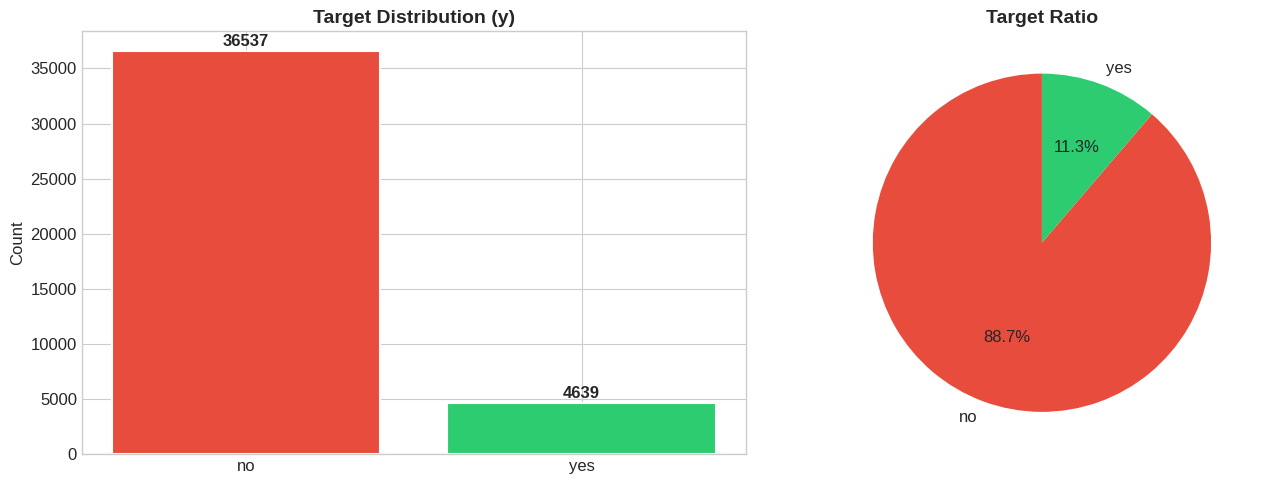

Imbalance ratio: 7.9 : 1


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df['y'].value_counts()
colors = ['#e74c3c', '#2ecc71']

ax = axes[0]
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
ax.set_title('Target Distribution (y)', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            str(val), ha='center', va='bottom', fontweight='bold')

ax = axes[1]
ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Target Ratio', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(REPORT_DIR + '/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Imbalance ratio:", round(counts['no'] / counts['yes'], 1), ": 1")

### 4.2 Categorical Analysis

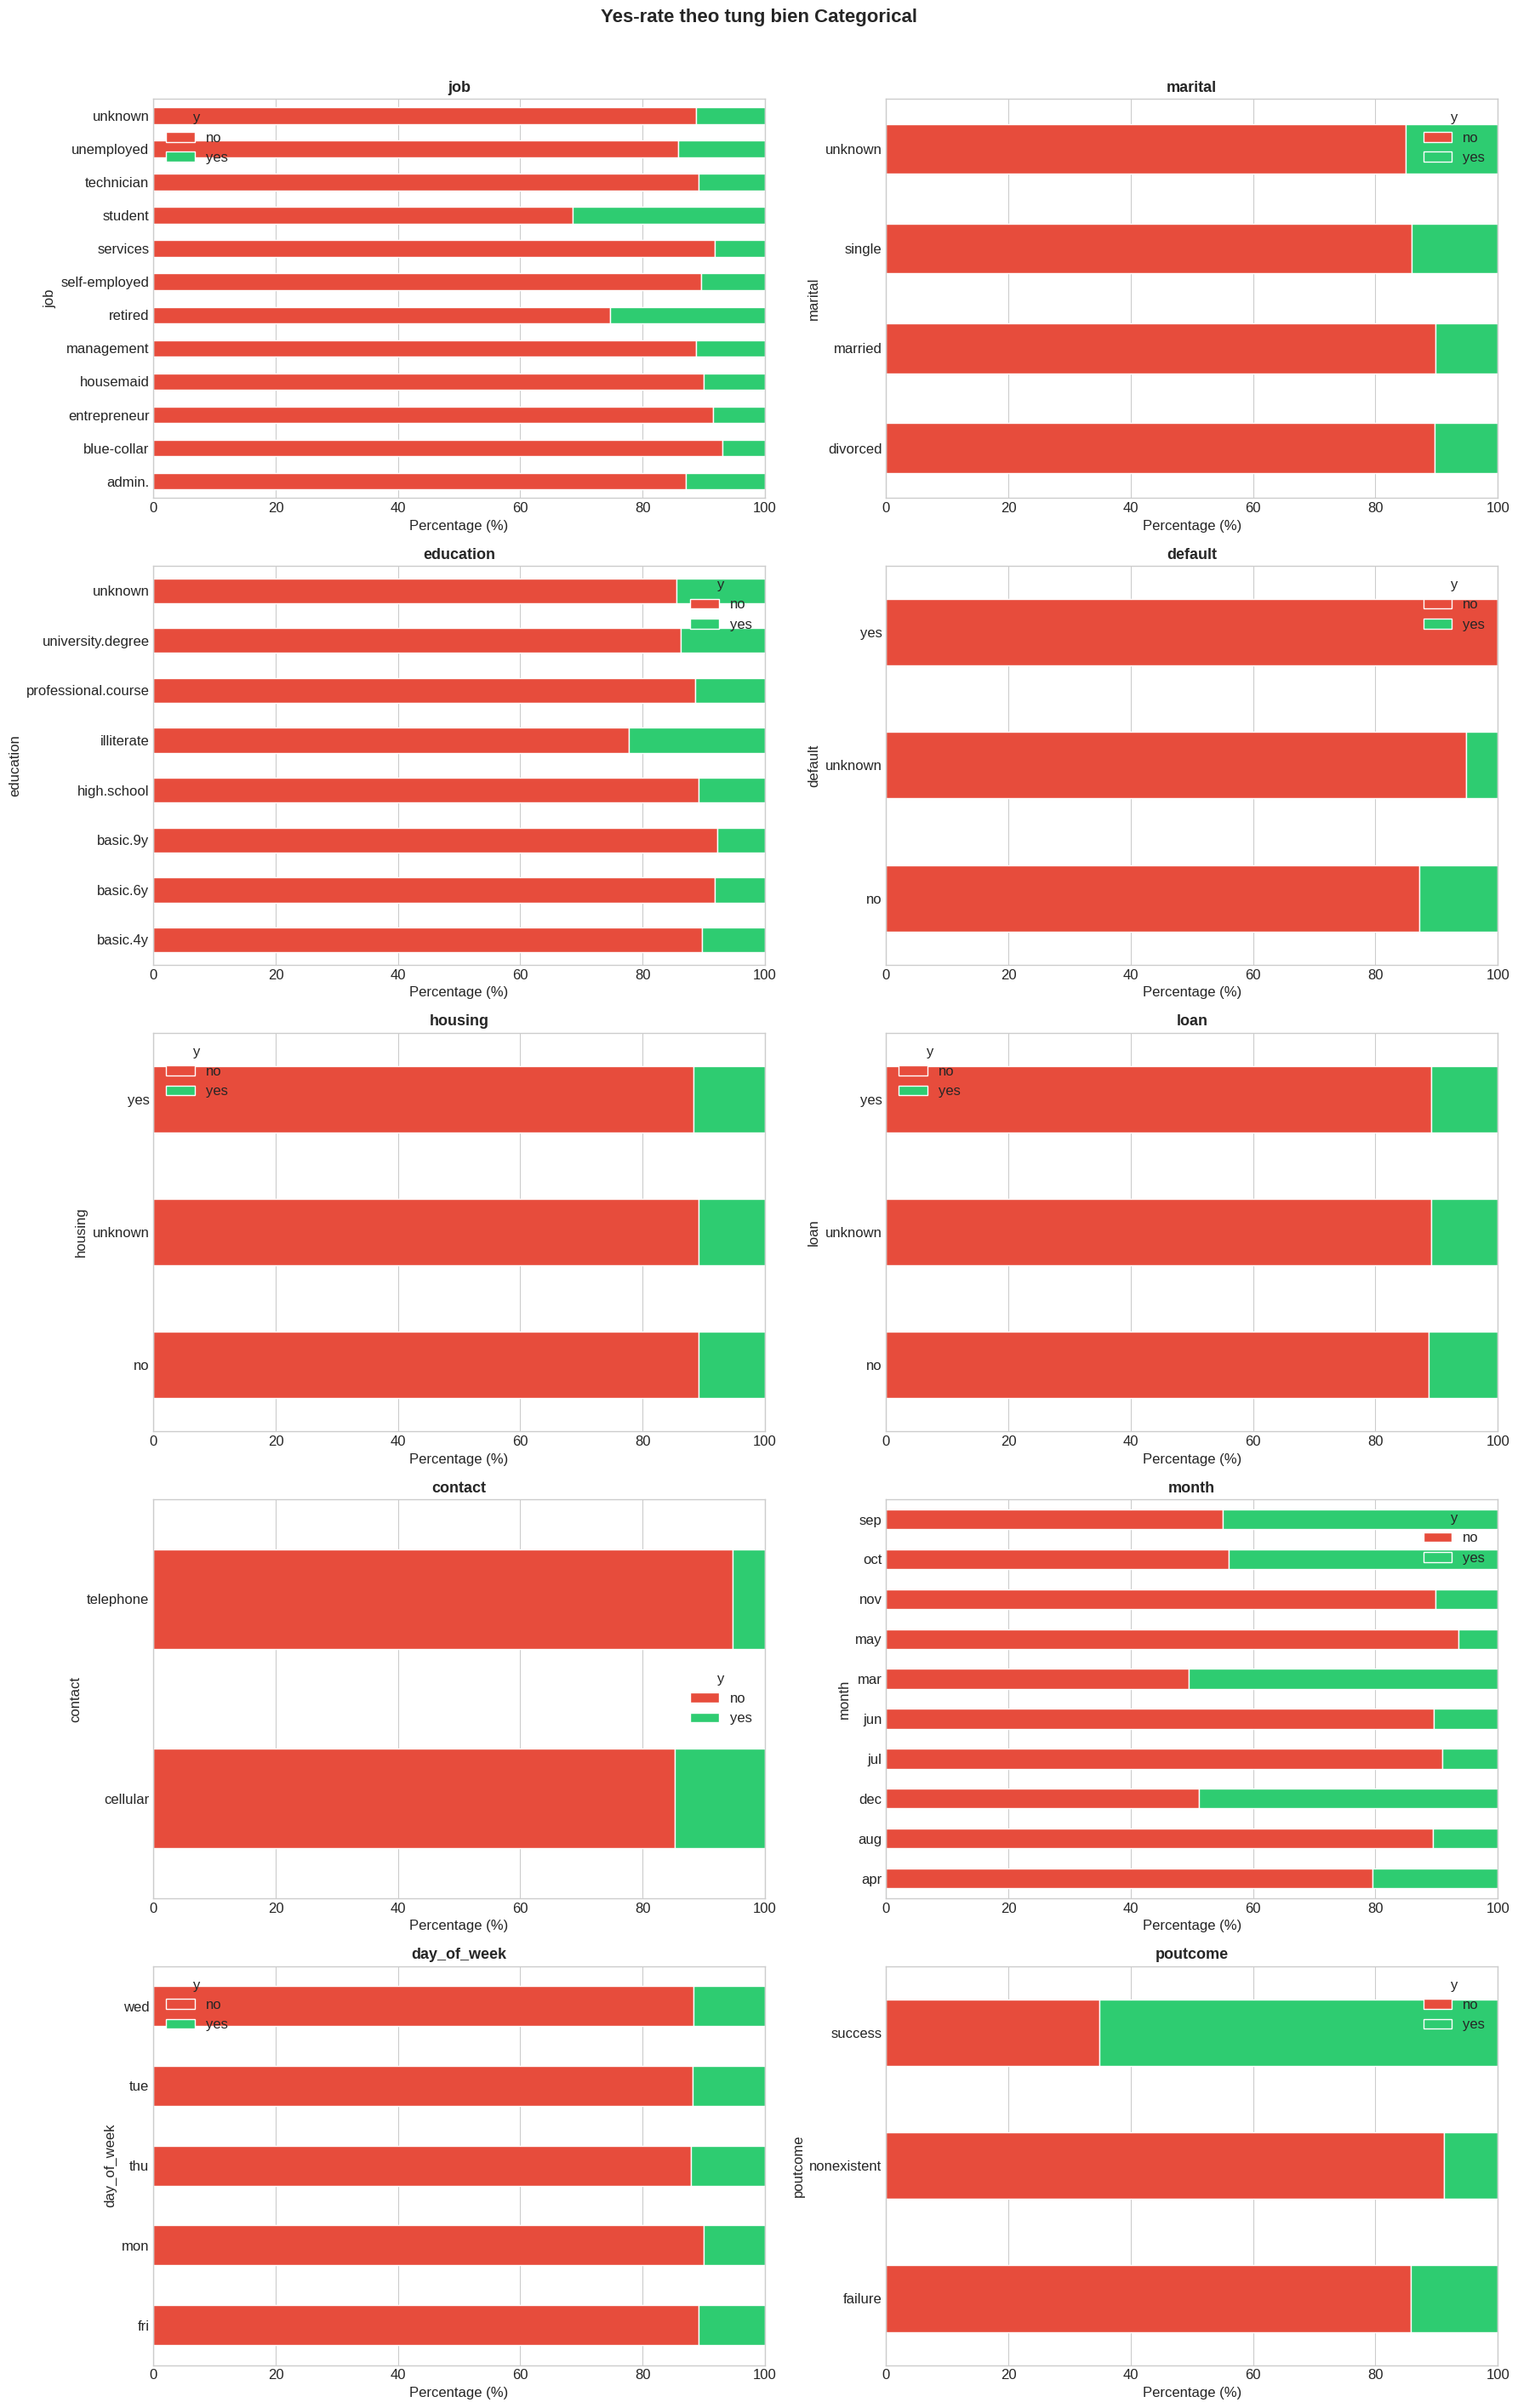

In [6]:
cat_features = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                'contact', 'month', 'day_of_week', 'poutcome']
fig, axes = plt.subplots(5, 2, figsize=(18, 28))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    ct = pd.crosstab(df[col], df['y'], normalize='index') * 100
    ct.plot(kind='barh', stacked=True, ax=axes[i], color=['#e74c3c', '#2ecc71'], edgecolor='white')
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Percentage (%)')
    axes[i].set_xlim(0, 100)
plt.suptitle('Yes-rate theo tung bien Categorical', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(REPORT_DIR + '/01_categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Numerical Distribution

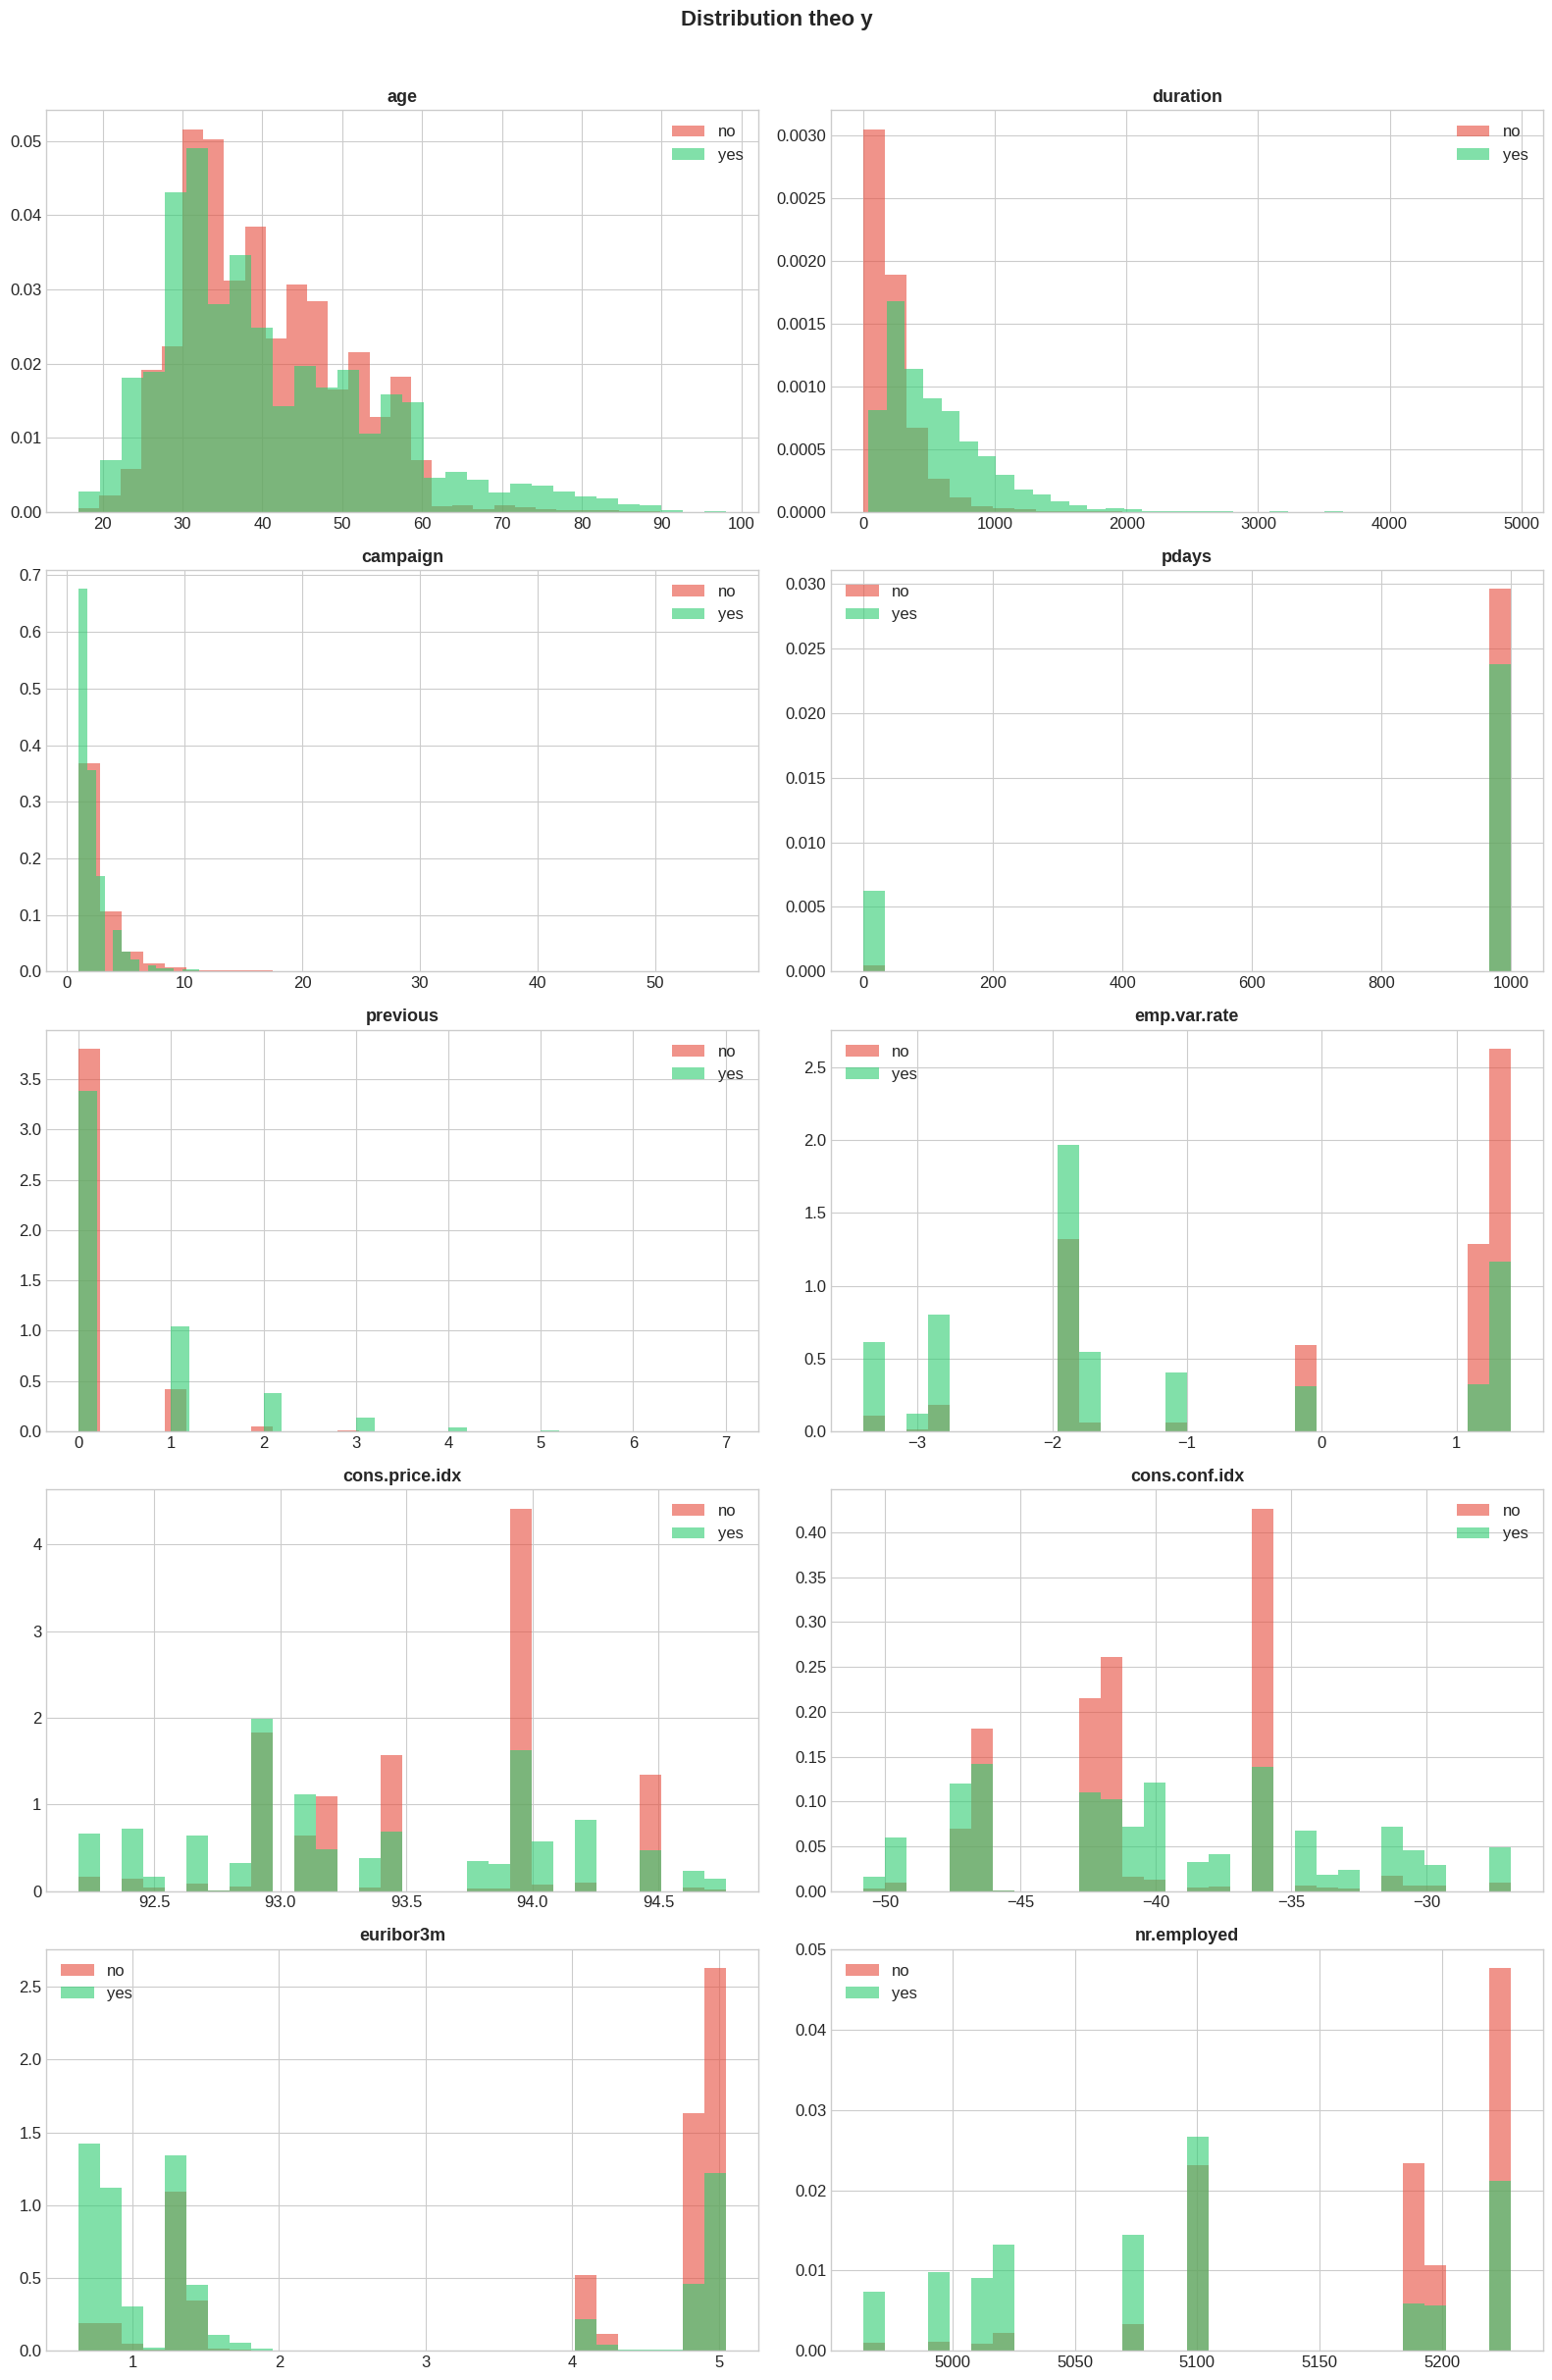

In [7]:
num_features = ['age', 'duration', 'campaign', 'pdays', 'previous',
                'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
fig, axes = plt.subplots(5, 2, figsize=(16, 24))
axes = axes.flatten()
for i, col in enumerate(num_features):
    df[df['y'] == 'no'][col].hist(ax=axes[i], bins=30, alpha=0.6, label='no', color='#e74c3c', density=True)
    df[df['y'] == 'yes'][col].hist(ax=axes[i], bins=30, alpha=0.6, label='yes', color='#2ecc71', density=True)
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].legend()
plt.suptitle('Distribution theo y', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(REPORT_DIR + '/01_numerical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Correlation Heatmap

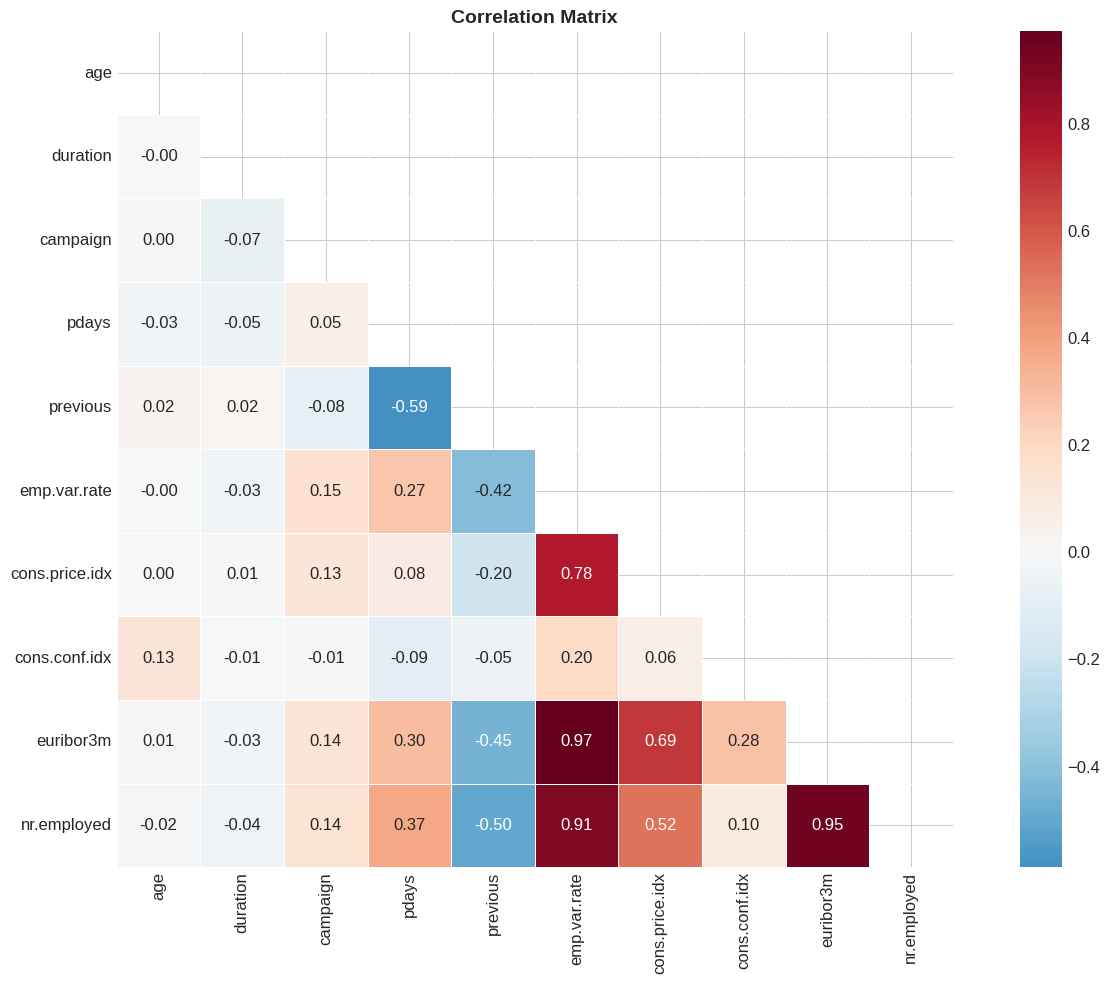

In [8]:
fig, ax = plt.subplots(figsize=(14, 10))
corr = df[num_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_DIR + '/01_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Boxplots

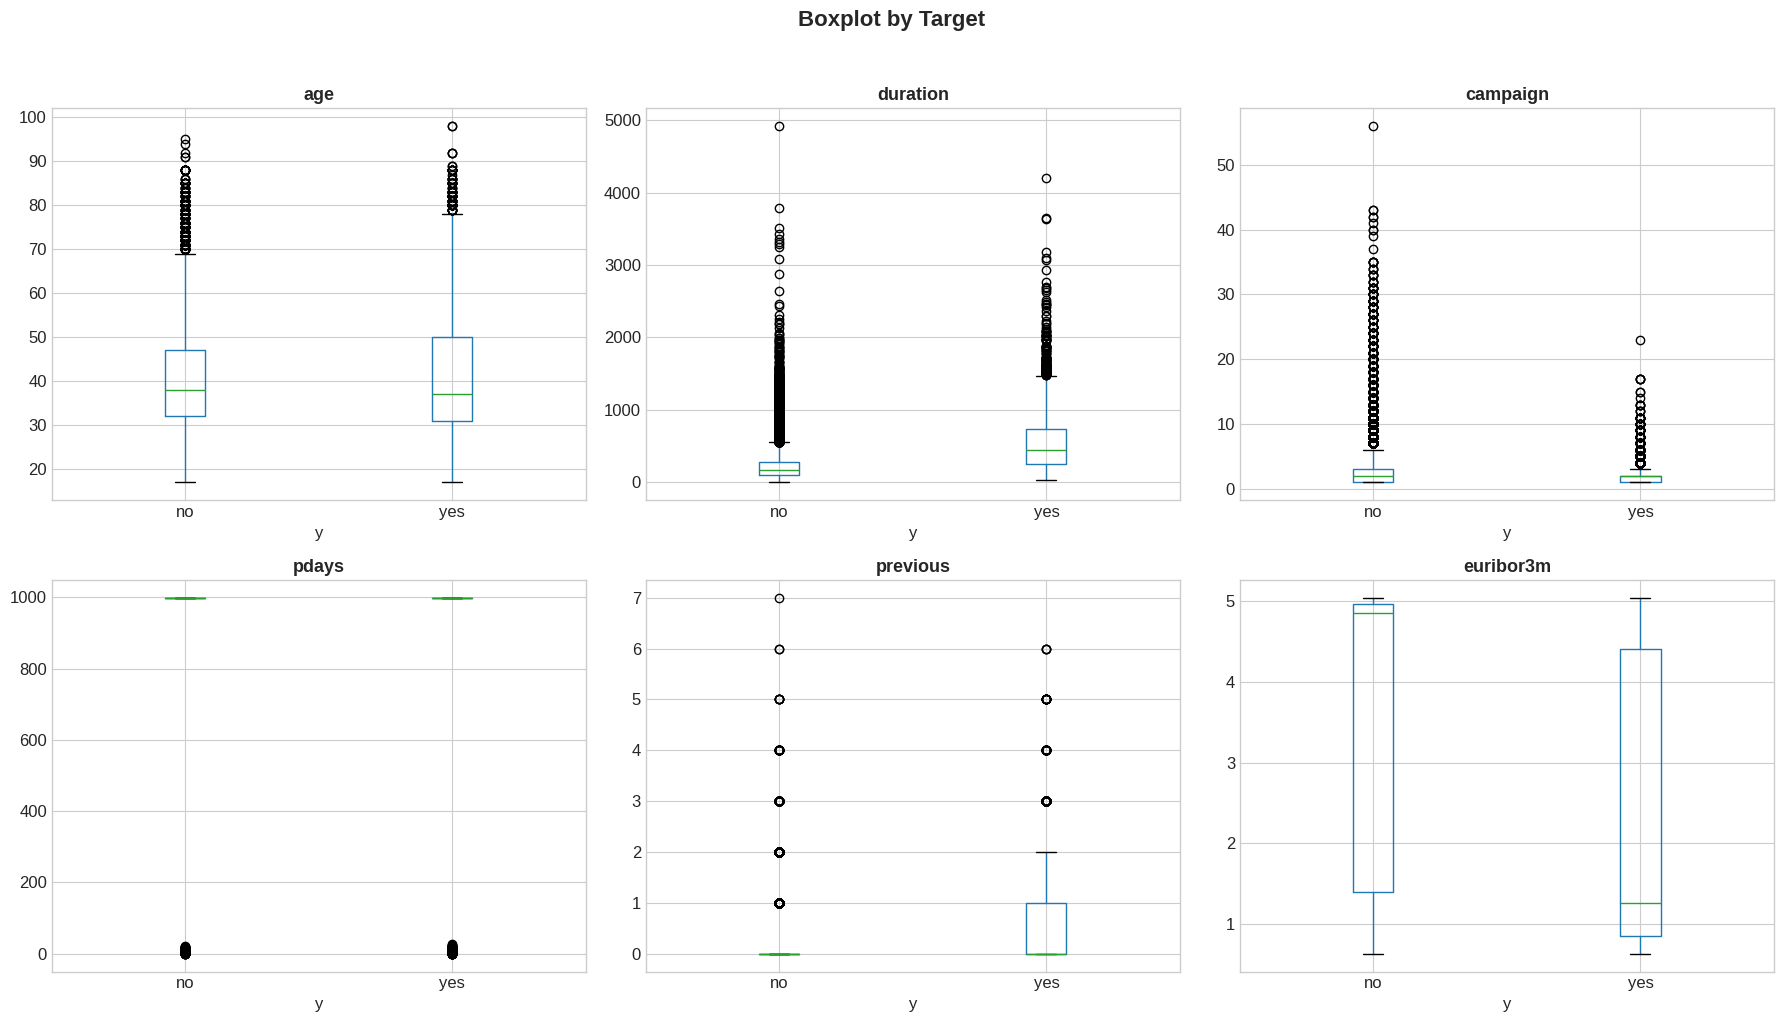

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
box_features = ['age', 'duration', 'campaign', 'pdays', 'previous', 'euribor3m']
for i, col in enumerate(box_features):
    df.boxplot(column=col, by='y', ax=axes.flatten()[i])
    axes.flatten()[i].set_title(col, fontsize=13, fontweight='bold')
plt.suptitle('Boxplot by Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR + '/01_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.6 Duration Analysis

> **Duration** = thoi luong cuoc goi (giay). Bien nay CHI biet SAU KHI cuoc goi ket thuc.
> Day la **prediction-time unavailability**, khong phai train/test leakage.
> Se tach thanh Scenario A (benchmark) va B (realistic) o NB02.

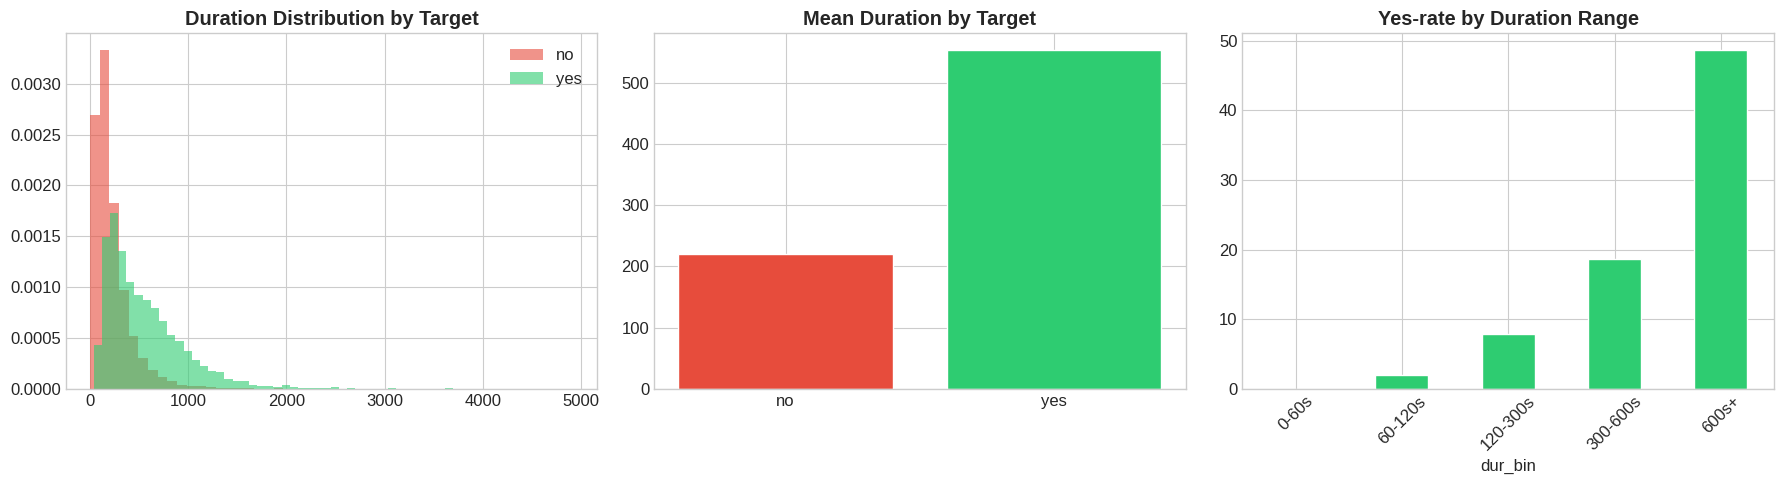

Duration: KHONG dung cho du doan truoc chien dich
Se tach thanh Scenario A/B o NB02


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df[df['y'] == 'no']['duration'].hist(ax=axes[0], bins=50, alpha=0.6, label='no', color='#e74c3c', density=True)
df[df['y'] == 'yes']['duration'].hist(ax=axes[0], bins=50, alpha=0.6, label='yes', color='#2ecc71', density=True)
axes[0].set_title('Duration Distribution by Target', fontweight='bold')
axes[0].legend()

means = df.groupby('y')['duration'].mean()
axes[1].bar(means.index, means.values, color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[1].set_title('Mean Duration by Target', fontweight='bold')

bins_d = [0, 60, 120, 300, 600, 5000]
labels_d = ['0-60s', '60-120s', '120-300s', '300-600s', '600s+']
df['dur_bin'] = pd.cut(df['duration'], bins=bins_d, labels=labels_d)
ct = pd.crosstab(df['dur_bin'], df['y'], normalize='index') * 100
ct['yes'].plot(kind='bar', ax=axes[2], color='#2ecc71', edgecolor='white')
axes[2].set_title('Yes-rate by Duration Range', fontweight='bold')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)
df.drop(columns='dur_bin', inplace=True)

plt.tight_layout()
plt.savefig(REPORT_DIR + '/01_duration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Duration: KHONG dung cho du doan truoc chien dich")
print("Se tach thanh Scenario A/B o NB02")

## 5. Tong ket NB01

| Chi so | Gia tri |
|---|---|
| Raw rows | 41,188 |
| Cleaned rows | ~41,176 |
| Columns | 21 |
| Null | 0 |
| Unknown | Co, giu nguyen |
| Class imbalance | ~89% no / ~11% yes |